In [2]:
# SECTION A - Loading the dataset
# (a)
import pandas as pd

# Load .csv file
df = pd.read_csv('IoT.csv')

# Set Display Precision for better Readability
pd.set_option('display.precision', 5)

# Handling of Mising Values
if df.isnull().sum().sum().sum() > 0:
    df = df.dropna()

print(df.info())
print (df.head(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   timestamp              150 non-null    object 
 1   soil_moisture_percent  150 non-null    float64
 2   temperature_celsius    150 non-null    float64
 3   humidity_percent       150 non-null    float64
 4   pump_status            150 non-null    int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 6.0+ KB
None
             timestamp  soil_moisture_percent  temperature_celsius  \
0  2026-01-10 06:00:00                  65.29                28.07   
1  2026-01-10 06:05:00                  39.41                19.93   
2  2026-01-10 06:10:00                  45.39                27.13   
3  2026-01-10 06:15:00                  49.89                31.14   
4  2026-01-10 06:20:00                  35.53                32.91   

   humidity_percent  pump_status  
0        


 Anomaly Summary:
                  Sensor  Anomaly Count
0  soil_moisture_percent              1
1    temperature_celsius              3
2       humidity_percent              4
3            pump_status              5


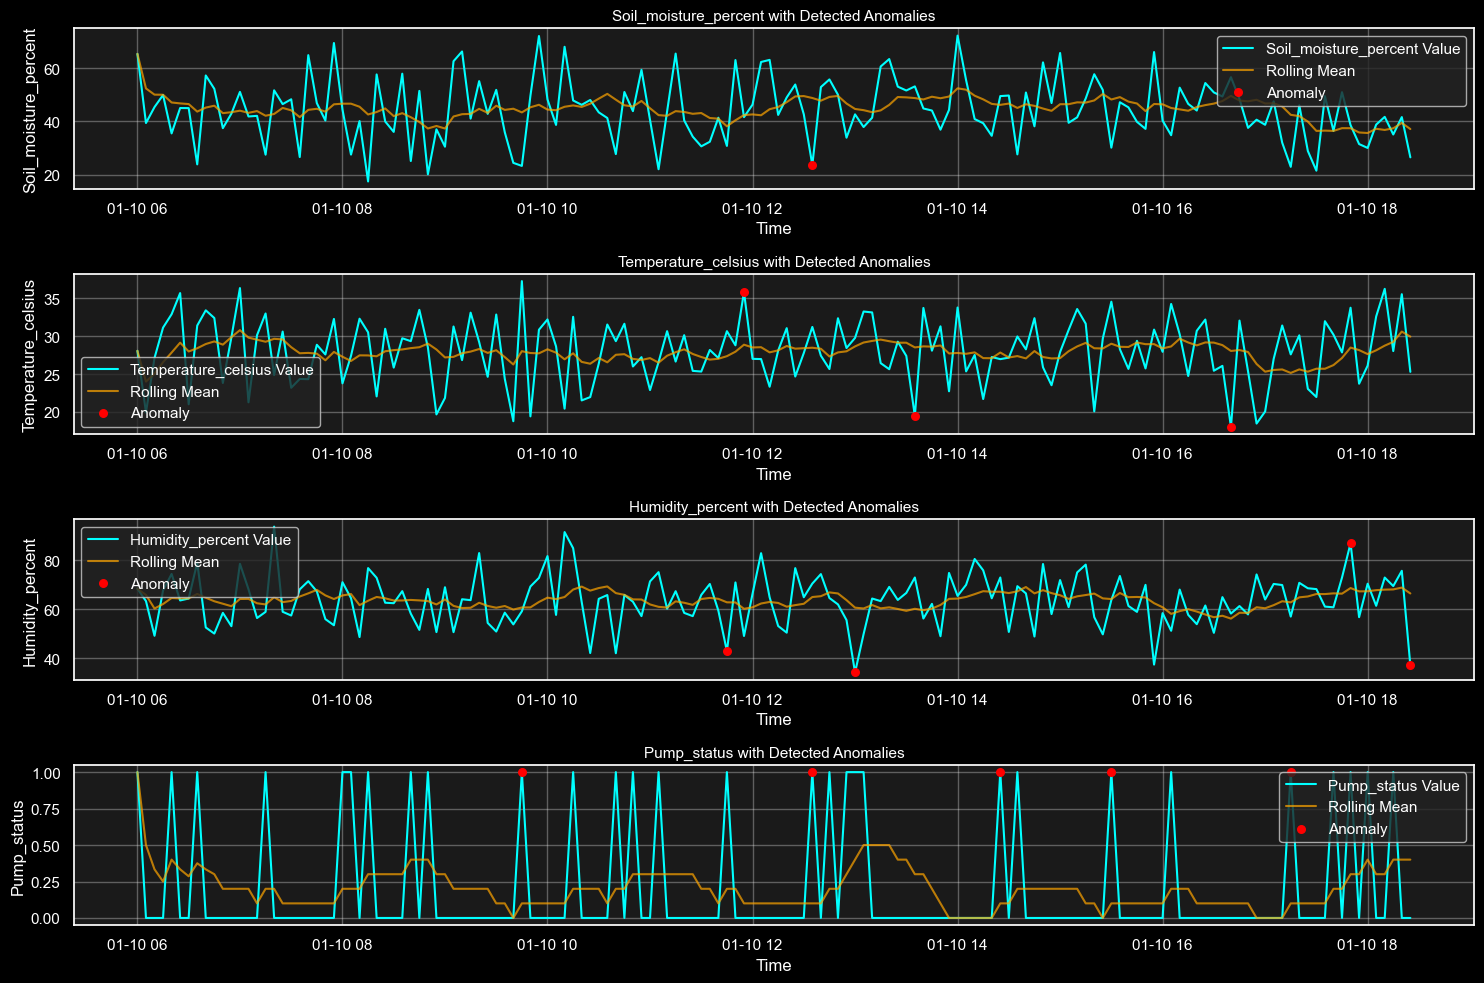

In [4]:
#2. Exploratory Data Analysis (EDA)
#2.1 Anomaly Detection


#Use rolling means and standard deviations to detect abnormal sensor behavior.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load and preprocess data 
df = pd.read_csv("IoT.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")

# Define numeric sensor columns
sensor_cols = ["soil_moisture_percent", "temperature_celsius", "humidity_percent", "pump_status"]

#  Compute rolling stats and detect anomalies
window = 10 

# adjust based on sensor frequency (e.g., 10 samples ~ 10 minutes)
threshold = 2  

# standard deviation threshold

for col in sensor_cols:
    df[f"{col}_rolling_mean"] = df[col].rolling(window=window, min_periods=1).mean()
    df[f"{col}_rolling_std"] = df[col].rolling(window=window, min_periods=1).std()
    
    # Detect anomalies: values outside mean ± (threshold × std)
    df[f"{col}_anomaly"] = (
        np.abs(df[col] - df[f"{col}_rolling_mean"]) > threshold * df[f"{col}_rolling_std"]
    )

#  Count anomalies per sensor 
anomaly_summary = df[[f"{c}_anomaly" for c in sensor_cols]].sum().reset_index()
anomaly_summary.columns = ["Sensor", "Anomaly Count"]
anomaly_summary["Sensor"] = anomaly_summary["Sensor"].str.replace("_anomaly", "")

print("\n Anomaly Summary:")
print(anomaly_summary)

#  Visualization: Anomaly plots per sensor 
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#1a1a1a", "figure.facecolor": "#000"})
plt.figure(figsize=(15, 10))

for i, col in enumerate(sensor_cols, 1):
    plt.subplot(len(sensor_cols), 1, i)
    plt.plot(df["timestamp"], df[col], label=f"{col.capitalize()} Value", color="cyan")
    plt.plot(df["timestamp"], df[f"{col}_rolling_mean"], label="Rolling Mean", color="orange", alpha=0.7)
    
    # Highlight anomalies
    anomalies = df[df[f"{col}_anomaly"]]
    plt.scatter(anomalies["timestamp"], anomalies[col], color="red", label="Anomaly", s=30, zorder=5)
    
    plt.title(f"{col.capitalize()} with Detected Anomalies", color="white", fontsize=11)
    plt.xlabel("Time", color="white")
    plt.ylabel(col.capitalize(), color="white")
    plt.legend(facecolor="#222", labelcolor="white")
    plt.grid(alpha=0.3)
    plt.xticks(color="white")
    plt.yticks(color="white")

plt.tight_layout()
plt.show()


In [10]:
# c) Compute the Mean, Min, and Max - Basic Statistical Summaries

import pandas as pd

# Load dataset
df = pd.read_csv("mock_dataset.csv", parse_dates=["timestamp"])
df.set_index("timestamp", inplace=True)

# Select sensor columns
sensors = ["soil_moisture_percent", "temperature_celsius", "humidity_percent", "pump_status"]

# Compute basic statistics
stats_summary = df[sensors].agg(["mean", "min", "median", "std", "max"])
df[f"{col}_rolling_std"] = df[col].rolling(window=window, min_periods=1).std()

print("Basic Statistical Summaries:\n")
print(stats_summary)

Basic Statistical Summaries:

        soil_moisture_percent  temperature_celsius  humidity_percent  \
mean                 50.55408             26.82192          60.30467   
min                  12.00000             17.00000          25.00000   
median               50.14000             27.17500          59.46500   
std                  15.32405              4.98688          11.88699   
max                  90.00000             40.00000          87.55000   

        pump_status  
mean        0.22500  
min         0.00000  
median      0.00000  
std         0.41933  
max         1.00000  


In [6]:
# c) Compute the Mean, Min, and Max - Basic Statistical Summaries

import pandas as pd

# Load dataset
df = pd.read_csv("IoT.csv", parse_dates=["timestamp"])
df.set_index("timestamp", inplace=True)

# Select sensor columns
sensors = ["soil_moisture_percent", "temperature_celsius", "humidity_percent", "pump_status"]

# Compute basic statistics
stats_summary = df[sensors].agg(["mean", "min", "max"])

print("Basic Statistical Summaries:\n")
print(stats_summary)

Basic Statistical Summaries:

      soil_moisture_percent  temperature_celsius  humidity_percent  \
mean               44.39727               28.041          63.58393   
min                17.54000               18.000          34.17000   
max                72.12000               37.290          93.61000   

      pump_status  
mean      0.19333  
min       0.00000  
max       1.00000  


Created line chart of soil moisture over time with pump status overlay and saved as soil_moisture_pump_status.png


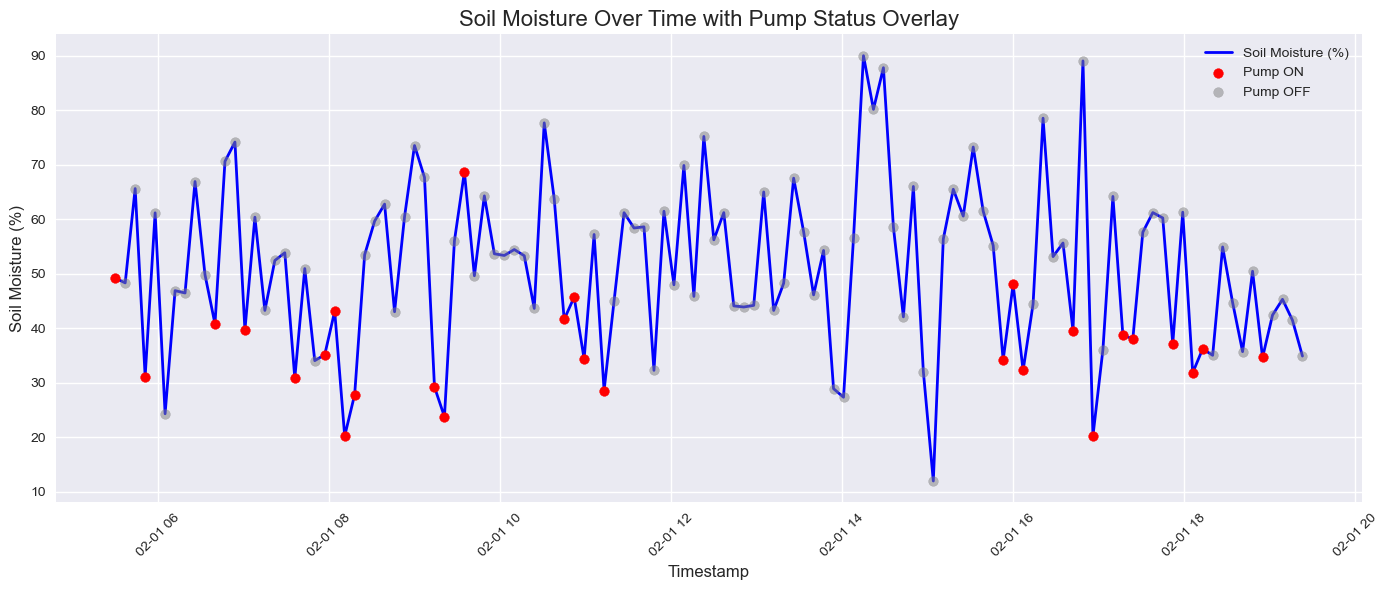

In [12]:
# Creating line chart of soil moisture over time with pump status overlay

import pandas as pd
import matplotlib.pyplot as plt
import os

# Load dataset
df = pd.read_csv('mock_dataset.csv')

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Create plot
plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots(figsize=(14, 6))

# Plot soil moisture as a line
ax.plot(df['timestamp'], df['soil_moisture_percent'], label='Soil Moisture (%)', color='blue', linewidth=2)

# Overlay pump status as markers
on_mask = df['pump_status'] == 1
off_mask = df['pump_status'] == 0

ax.scatter(df.loc[on_mask, 'timestamp'], df.loc[on_mask, 'soil_moisture_percent'],
           color='red', label='Pump ON', zorder=5)

ax.scatter(df.loc[off_mask, 'timestamp'], df.loc[off_mask, 'soil_moisture_percent'],
           color='grey', label='Pump OFF', alpha=0.5, zorder=4)

# Formatting
ax.set_title('Soil Moisture Over Time with Pump Status Overlay', fontsize=16)
ax.set_xlabel('Timestamp', fontsize=12)
ax.set_ylabel('Soil Moisture (%)', fontsize=12)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()

# Save plot
#output_path = '/mnt/data/soil_moisture_pump_status.png'
#plt.savefig(output_path)

print("Created line chart of soil moisture over time with pump status overlay and saved as soil_moisture_pump_status.png")

In [5]:
import docx

def read_docx(file_path):
    doc = doc.Document(file_path)
    full_text = []
    for para in doc.paragraphs:
        full_text.append(para.text)
        return '\n'.join(full_text)

        text = read_docx ('A.doc')
        print (text)
        

In [7]:
from pypdf import PdfReader
reader = PdfReader("A.pdf")
text = ""
for page in reader.pages:
    text += page.extract_text() + "\n"

    print (text)

Q) This dataset represents sensor readings from a smart irrigation system. Each row logs 
environmental conditions and pump activity at specific timestamps. 
What it represents 
• Timestamp: The exact time of measurement. 
• Soil moisture (%): Indicates how much water is present in the soil. 
• Temperature (°C): Tracks ambient temperature, which affects evaporation and plant 
water needs. 
• Humidity (%): Measures air moisture, influencing how quickly soil dries. 
• Pump status (0/1): Shows whether the irrigation pump was off (0) or on (1). 
Why it is important 
• Efficient water use: By monitoring soil moisture, the system can activate the pump only 
when plants actually need water, preventing waste. 
• Crop health: Balancing soil moisture with temperature and humidity ensures plants 
receive optimal growing conditions. 
• Automation & sustainability: The dataset enables predictive control—using patterns to 
automate irrigation schedules, reduce manual labor, and conserve resources. 
